# **Predicting Seasonal Influenza Vaccination Uptake Through  A Comparative Machine Learning Approach**

## **1. Project Overview & Business Problem**

## **1.1 Business Problem**

Every year, seasonal influenza causes significant mortality and economic loss due to healthcare costs and lost productivity. While vaccines are widely available, a large portion of the population remains unvaccinated. Public health organizations require a precise, data-driven method to identify which demographic and behavioral key factors highly influence an individual's decision to get vaccinated.

---

### **Objective:**

The goal of this project is to build a **predictive machine learning model** that identifies the key factors that influence whether an individual receives the seasonal flu vaccine or not. This helps healthcare providers allocate resources more efficiently and allows for targeted communication strategies that increase overall vaccination rates.


***

## **1.2 Business Understanding**

 ### ***1.2.1 Key Stakeholders:***

1. ***Global Health Organizations (WHO / UNICEF)***
- Responsible for studying broad behavioral trends to update global policy and combat misinformation.

2. ***National & Local Health Departments (e.g., Ministry of Health):*** 
- Responsible for identifying which populations are mostly unvaccinated and use this to allocate their limited budgets to the right neighborhoods.

3. ***Public Health Marketing Teams:*** 
- To design effective awareness campaigns.

4. ***Healthcare Providers & Clinics:*** 
- They can use model's insights to improve patient-doctor communication especially to the unlikely-to-vaccinate" patients.

5. ***Pharmaceutical Supply Chain Managers:*** 
- They derive vaccination probabilities to predict regional vaccine demand, preventing both shortages and medicine waste.

6. ***Health Insurance Companies:***
- They benefit from the reduced clinical costs associated with influenza due to higher community immunization rates.


***

### ***1.2.2 Key Goals***

1. ***Classification Model:*** Build a classification model with an AUC score above 0.75 that distinguishes between vaccinated and unvaccinated individuals, allowing for more effective health intervention strategies.


2. ***Feature Analysis Report:*** Identify the top 5 features that highly influence vaccination behavior.


3. ***Minimize the Generalization Gap:*** This is to ensure the model performs reliably on real-world, unseen survey data.

***

## **2. Data Understanding**

 ### ***2.1 Data Source:***

The data for this project is sourced from the `National 2009 H1N1 Flu Survey (NHFS)`. While the survey was conducted during the H1N1 pandemic, it collected extensive data on Seasonal Flu vaccination patterns, which serves as our target variable.

This dataset is ideal for behavioral insights because it captures personal opinions and daily habits.

#### Importing Libraries

In [1]:
#Import the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

%matplotlib inline


#### Loading Datasets

We will specifically use the `training_set_features` & `training_set_labels` datasets for our project.

In [2]:
#Load datasets

data1 = pd.read_csv("training_set_features.csv")
data2 = pd.read_csv("training_set_labels.csv")

# Merg data1 and data2 using the respondent_id as the reference variable
df = pd.merge(data2,data1,how='left')

In [3]:
# Check shape
df.shape

(26707, 38)

In [4]:
df.head().T

,0,1,2,3,4
respondent_id,0,1,2,3,4
h1n1_vaccine,0,0,0,0,0
seasonal_vaccine,0,1,0,1,0
h1n1_concern,1,3,1,1,2
h1n1_knowledge,0,2,1,1,1
behavioral_antiviral_meds,0,0,0,0,0
behavioral_avoidance,0,1,1,1,1
behavioral_face_mask,0,0,0,0,0
behavioral_wash_hands,0,1,0,1,1
behavioral_large_gatherings,0,0,0,1,1


In [5]:
# Check info
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_vaccine                 26707 non-null  int64  
 2   seasonal_vaccine             26707 non-null  int64  
 3   h1n1_concern                 26615 non-null  float64
 4   h1n1_knowledge               26591 non-null  float64
 5   behavioral_antiviral_meds    26636 non-null  float64
 6   behavioral_avoidance         26499 non-null  float64
 7   behavioral_face_mask         26688 non-null  float64
 8   behavioral_wash_hands        26665 non-null  float64
 9   behavioral_large_gatherings  26620 non-null  float64
 10  behavioral_outside_home      26625 non-null  float64
 11  behavioral_touch_face        26579 non-null  float64
 12  doctor_recc_h1n1             24547 non-null  float64
 13  doctor_recc_seas

 ### ***2.2 Dataset Characteristics:***

- **Total Records:** We have 26,707 survey responses.


- **Feature Set:** 37 predictor variables, including:

  **1. Behavioral:** (e.g., behavioral_face_mask, behavioral_wash_hands).

  **2. Opinions:** (e.g., opinion_seas_vacc_effective, opinion_seas_sick_from_vacc).

  **3. Demographics:** (e.g., age_group, education, race, income_poverty).

  **4. Health History:** (e.g., doctor_recc_seasonal, chronic_med_condition).

 ### **2.3 Target Variable Analysis:**

The target variable is **seasonal_vaccine:**

**0:** Did not receive the seasonal flu vaccine.

**1:** Received the seasonal flu vaccine.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
respondent_id,26707.0,13353.000000,7709.791156,0.0,6676.5,13353.0,20029.5,26706.0
h1n1_vaccine,26707.0,0.212454,0.409052,0.0,0.0,0.0,0.0,1.0
seasonal_vaccine,26707.0,0.465608,0.498825,0.0,0.0,0.0,1.0,1.0
h1n1_concern,26615.0,1.618486,0.910311,0.0,1.0,2.0,2.0,3.0
h1n1_knowledge,26591.0,1.262532,0.618149,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,26636.0,0.048844,0.215545,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,26499.0,0.725612,0.446214,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,26688.0,0.068982,0.253429,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,26665.0,0.825614,0.379448,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,26620.0,0.358640,0.479610,0.0,0.0,0.0,1.0,1.0


## **3. Data Preparation and Pre-Processing**

1. Check for duplicates
2. Drop irrelevant columns
3. Apply train-test split
4. Detect and deal with missing values
5. Convert categorical data to numeric format through one-hot encoding
6. Normalize our numeric data
7. Check for and remove multicollinearity (correlated predictors)

### 3.1 Check for duplicates

In [7]:
# Find duplicated values
df.duplicated().sum()

0

### 3.2 Drop irrelevant columns

In [8]:
# Check for missing values' percentages to determine which columns to keep & drop
df.isna().mean()*100

respondent_id                   0.000000
h1n1_vaccine                    0.000000
seasonal_vaccine                0.000000
h1n1_concern                    0.344479
h1n1_knowledge                  0.434343
behavioral_antiviral_meds       0.265848
behavioral_avoidance            0.778822
behavioral_face_mask            0.071142
behavioral_wash_hands           0.157262
behavioral_large_gatherings     0.325757
behavioral_outside_home         0.307036
behavioral_touch_face           0.479275
doctor_recc_h1n1                8.087767
doctor_recc_seasonal            8.087767
chronic_med_condition           3.635751
child_under_6_months            3.070356
health_worker                   3.010447
health_insurance               45.957989
opinion_h1n1_vacc_effective     1.464036
opinion_h1n1_risk               1.452803
opinion_h1n1_sick_from_vacc     1.479013
opinion_seas_vacc_effective     1.729884
opinion_seas_risk               1.924589
opinion_seas_sick_from_vacc     2.010709
age_group       

There are columns with many missing values. Therefore, we drop columns with missing values' percentages of 40% & above and columns related to H1N1 vaccine as my focus is on the Seasonal Flu vaccine.


We also drop `hhs_geo_region` because it's an anonymized categorical variable in that it lacks interpretability and `respondent_id` because it just contains the unique identifiers.

In [9]:
# Drop irrelevant columns
columns_to_drop = ['respondent_id','h1n1_vaccine', 'h1n1_concern', 'h1n1_knowledge', 'doctor_recc_h1n1', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'health_insurance', 'income_poverty', 'employment_industry', 'employment_occupation', 'hhs_geo_region']

df.drop(columns= columns_to_drop, inplace=True)

In [10]:
# Check remaining columns
df.columns

Index(['seasonal_vaccine', 'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'opinion_seas_vacc_effective', 'opinion_seas_risk',
       'opinion_seas_sick_from_vacc', 'age_group', 'education', 'race', 'sex',
       'marital_status', 'rent_or_own', 'employment_status', 'census_msa',
       'household_adults', 'household_children'],
      dtype='object')

In [11]:
df.select_dtypes(include="number").info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26707 entries, 0 to 26706
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   seasonal_vaccine             26707 non-null  int64  
 1   behavioral_antiviral_meds    26636 non-null  float64
 2   behavioral_avoidance         26499 non-null  float64
 3   behavioral_face_mask         26688 non-null  float64
 4   behavioral_wash_hands        26665 non-null  float64
 5   behavioral_large_gatherings  26620 non-null  float64
 6   behavioral_outside_home      26625 non-null  float64
 7   behavioral_touch_face        26579 non-null  float64
 8   doctor_recc_seasonal         24547 non-null  float64
 9   chronic_med_condition        25736 non-null  float64
 10  child_under_6_months         25887 non-null  float64
 11  health_worker                25903 non-null  float64
 12  opinion_seas_vacc_effective  26245 non-null  float64
 13  opinion_seas_ris

In [12]:
df.select_dtypes(include="object").info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26707 entries, 0 to 26706
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age_group          26707 non-null  object
 1   education          25300 non-null  object
 2   race               26707 non-null  object
 3   sex                26707 non-null  object
 4   marital_status     25299 non-null  object
 5   rent_or_own        24665 non-null  object
 6   employment_status  25244 non-null  object
 7   census_msa         26707 non-null  object
dtypes: object(8)
memory usage: 1.8+ MB


### 3.3 Train-Test Split

In [13]:
# Define predictors(X) and target(y) variables

X = df.drop(["seasonal_vaccine"], axis=1)
y = df["seasonal_vaccine"]

In [14]:
# Apply train-test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.head()

,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,...,age_group,education,race,sex,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children
24706,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,45 - 54 Years,Some College,White,Female,Married,Rent,Unemployed,"MSA, Not Principle City",1.0,0.0
5393,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,45 - 54 Years,College Graduate,White,Male,Not Married,Own,Employed,"MSA, Not Principle City",0.0,0.0
20898,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,35 - 44 Years,NaN,White,Male,Married,NaN,Employed,"MSA, Not Principle City",1.0,1.0
3429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,45 - 54 Years,College Graduate,Other or Multiple,Female,Not Married,Own,Employed,Non-MSA,0.0,0.0
8731,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,65+ Years,College Graduate,Black,Female,Not Married,Own,Not in Labor Force,"MSA, Principle City",1.0,1.0


### 3.4 Handling missing values

We will use the `Simple Imputer` to impute missing values.

#### 3.4.1 Training data

In [15]:
X_train.head().T

,24706,5393,20898,3429,8731
behavioral_antiviral_meds,0,1,0,0,0
behavioral_avoidance,1,1,0,0,0
behavioral_face_mask,0,1,0,0,0
behavioral_wash_hands,1,1,1,0,1
behavioral_large_gatherings,0,1,0,0,0
behavioral_outside_home,1,1,1,0,0
behavioral_touch_face,1,1,0,0,0
doctor_recc_seasonal,0,0,0,0,0
chronic_med_condition,1,0,0,0,0
child_under_6_months,0,0,0,0,0


In [16]:
# Perform imputation on X_train to fill missing values

# Define imputers
numeric_imputer = SimpleImputer(strategy='most_frequent')
categorical_imputer = SimpleImputer(strategy='most_frequent')

# Create X_train categorical and numeric columns variables
train_numeric_cols = X_train.select_dtypes(include="number").columns
train_categorical_cols = X_train.select_dtypes(include="object").columns

# Make a copy of X_train df to preserve original X_train df
X_train_filledna = X_train.copy()

# imputer.fit_transform(X_train_filledna[numeric_columns])
X_train_filledna[train_numeric_cols] = pd.DataFrame(numeric_imputer.fit_transform(X_train_filledna[train_numeric_cols]),
                           index = X_train_filledna.index,
                           columns = train_numeric_cols)

# imputer.fit_transform(X_train_filledna[categorical_columns])
X_train_filledna[train_categorical_cols] = pd.DataFrame(categorical_imputer.fit_transform(X_train_filledna[train_categorical_cols]),
                           index = X_train_filledna.index,
                           columns = train_categorical_cols)

In [17]:
# Confirim imputation of missing values on training data
X_train_filledna.isna().sum()

behavioral_antiviral_meds      0
behavioral_avoidance           0
behavioral_face_mask           0
behavioral_wash_hands          0
behavioral_large_gatherings    0
behavioral_outside_home        0
behavioral_touch_face          0
doctor_recc_seasonal           0
chronic_med_condition          0
child_under_6_months           0
health_worker                  0
opinion_seas_vacc_effective    0
opinion_seas_risk              0
opinion_seas_sick_from_vacc    0
age_group                      0
education                      0
race                           0
sex                            0
marital_status                 0
rent_or_own                    0
employment_status              0
census_msa                     0
household_adults               0
household_children             0
dtype: int64

#### 3.4.2 Test data

In [18]:
X_test.head().T

,15772,9407,16515,23353,10008
behavioral_antiviral_meds,0,0,0,0,0
behavioral_avoidance,1,1,1,1,1
behavioral_face_mask,1,1,0,0,0
behavioral_wash_hands,1,1,1,1,1
behavioral_large_gatherings,1,1,1,0,1
behavioral_outside_home,1,1,1,0,0
behavioral_touch_face,1,0,1,0,1
doctor_recc_seasonal,0,NaN,1,0,0
chronic_med_condition,NaN,NaN,0,0,0
child_under_6_months,NaN,NaN,0,0,1


In [19]:
# Performi imputation on X_test to fill missing values

# Create X_test categorical and numeric columns variables
test_numeric_cols = X_test.select_dtypes(include="number").columns
test_categorical_cols = X_test.select_dtypes(include="object").columns

# Make a copy of X_test df to preserve original X_test df
X_test_filledna = X_test.copy()

# imputer.transform(X_test_filledna[numeric_columns])
X_test_filledna[test_numeric_cols] = pd.DataFrame(numeric_imputer.transform(X_test_filledna[test_numeric_cols]),
                           index = X_test_filledna.index,
                           columns = test_numeric_cols)

# imputer.transform(X_test_filledna[categorical_columns])
X_test_filledna[test_categorical_cols] = pd.DataFrame(categorical_imputer.transform(X_test_filledna[test_categorical_cols]),
                           index = X_test_filledna.index,
                           columns = test_categorical_cols)

In [20]:
# Confirim imputation of missing values on test data
X_test_filledna.isna().sum()

behavioral_antiviral_meds      0
behavioral_avoidance           0
behavioral_face_mask           0
behavioral_wash_hands          0
behavioral_large_gatherings    0
behavioral_outside_home        0
behavioral_touch_face          0
doctor_recc_seasonal           0
chronic_med_condition          0
child_under_6_months           0
health_worker                  0
opinion_seas_vacc_effective    0
opinion_seas_risk              0
opinion_seas_sick_from_vacc    0
age_group                      0
education                      0
race                           0
sex                            0
marital_status                 0
rent_or_own                    0
employment_status              0
census_msa                     0
household_adults               0
household_children             0
dtype: int64

In [21]:
X_test_filledna.head().T

,15772,9407,16515,23353,10008
behavioral_antiviral_meds,0,0,0,0,0
behavioral_avoidance,1,1,1,1,1
behavioral_face_mask,1,1,0,0,0
behavioral_wash_hands,1,1,1,1,1
behavioral_large_gatherings,1,1,1,0,1
behavioral_outside_home,1,1,1,0,0
behavioral_touch_face,1,0,1,0,1
doctor_recc_seasonal,0,0,1,0,0
chronic_med_condition,0,0,0,0,0
child_under_6_months,0,0,0,0,1


### 3.5 One-Hot-Encoding

The dataset contains several categorical variables which are stored as strings. Since machine learning algorithms operate on mathematical equations, they cannot process text directly. I'll transform these categories into a numeric format using One-Hot-Encoding.

#### 3.5.1 Training data

In [22]:
# One-Hot-Encode training data

# Create a copy of the categorical columns from the filled training set
X_train_categorical = X_train_filledna[train_categorical_cols].copy()

# Initialize the encoder and drop the first category to avoid multicollinearity
ohe = OneHotEncoder(drop='first',sparse=False)

# fit_transform test set using ohe
X_train_ohe = pd.DataFrame(ohe.fit_transform(X_train_categorical),
                                index = X_train_filledna.index,
                                columns = ohe.get_feature_names_out(train_categorical_cols))
X_train_ohe.head()

,age_group_35 - 44 Years,age_group_45 - 54 Years,age_group_55 - 64 Years,age_group_65+ Years,education_< 12 Years,education_College Graduate,education_Some College,race_Hispanic,race_Other or Multiple,race_White,sex_Male,marital_status_Not Married,rent_or_own_Rent,employment_status_Not in Labor Force,employment_status_Unemployed,"census_msa_MSA, Principle City",census_msa_Non-MSA
24706,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
5393,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
20898,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3429,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
8731,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


#### 3.5.2 Test data

In [23]:
# One-Hot-Encode test data

# Create a copy of the categorical columns from the filled test set
X_test_categorical = X_test_filledna[test_categorical_cols].copy()

# transform test set using ohe
X_test_ohe = pd.DataFrame(ohe.transform(X_test_categorical),
                                index = X_test_filledna.index,
                                columns = ohe.get_feature_names_out(test_categorical_cols))
X_test_ohe

,age_group_35 - 44 Years,age_group_45 - 54 Years,age_group_55 - 64 Years,age_group_65+ Years,education_< 12 Years,education_College Graduate,education_Some College,race_Hispanic,race_Other or Multiple,race_White,sex_Male,marital_status_Not Married,rent_or_own_Rent,employment_status_Not in Labor Force,employment_status_Unemployed,"census_msa_MSA, Principle City",census_msa_Non-MSA
15772,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9407,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
16515,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
23353,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10008,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25132,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20086,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
5045,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
6340,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


### 3.6 Normalize our numeric data

In this dataset, most of the numeric features are already on a very small similar scale hence normalizing numeric data is unnecessary. Some of the numeric features include;

- Binary features (e.g., behavioral_antiviral_meds) : 0 or 1.
- Opinion features (e.g., opinion_seas_sick_from_vacc	) : 1, 2, 3, 4, 5.
- Household counts (e.g., household_children): small integers (0, 1, 2, 3).

### 3.7 Check for and remove multicollinearity (correlated predictors)

We will use a `correlation heatmap` to inspect the relationships between the 16 numeric predictors and use `variance_inflation_factor` to inspect the one-hot-encoded predictors.

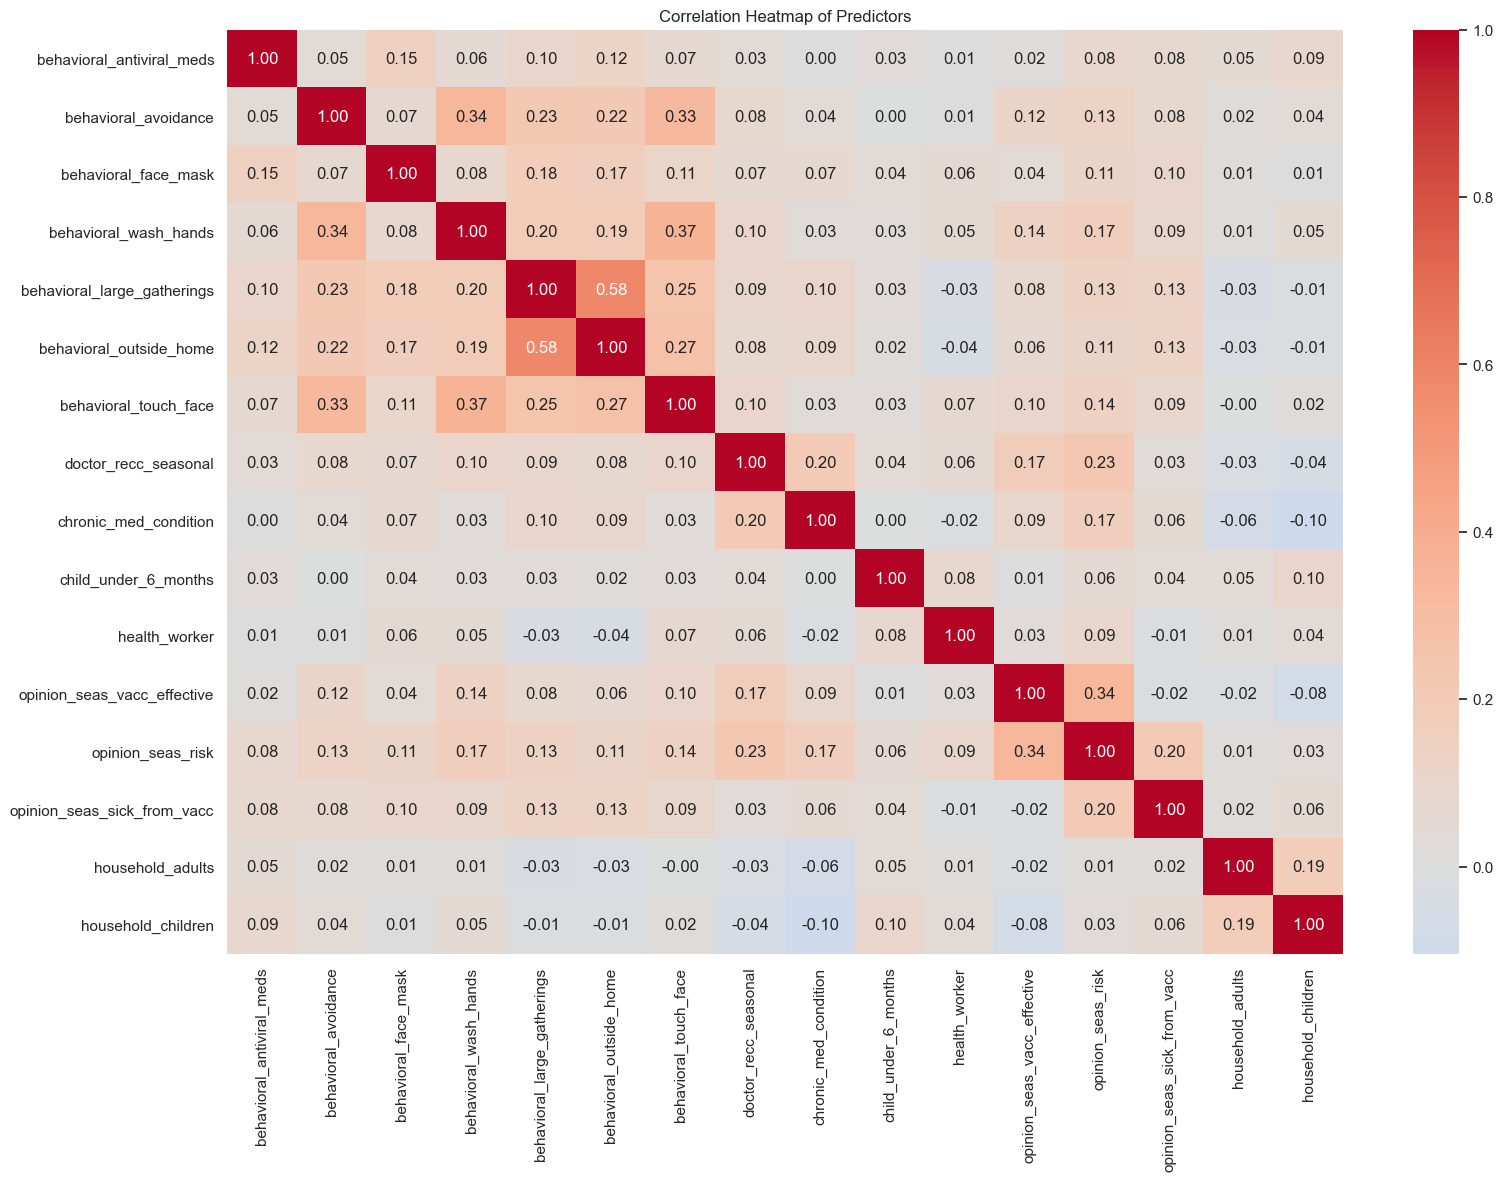

In [24]:
# 1. Calculate the correlation matrix for numeric columns
corr_matrix = X_train_filledna[train_numeric_cols].corr()

# 2. Plot the heatmap
plt.figure(figsize=(18, 12))
sns.set(font_scale = 1.0)
sns.heatmap(corr_matrix, annot=True, fmt = '.2f', center=0, cmap='coolwarm')
plt.title("Correlation Heatmap of Predictors")
plt.show()

### Interpretation

`behavioral_outside_home` and `behavioral_large_gatherings` have a peach-colored square where these intersect and they have a correlation of **0.58**.

This means that people who avoid large gatherings are also very likely to avoid going outside the home. This means the Heatmap captures similar "cautious" behavior.

Since we don't have correlations higher than **0.8** off the diagonal line (every feature has a correlation of 1.0 with itself), this means our model will be able to distinguish between these features easily thus we don't need to drop any of these 16 columns based on this Heatmap alone. 

In [25]:
# Add a constant column to the dataset for intercept
X = add_constant(X_train_ohe)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF data
print(vif_data)

                                 feature        VIF
0                                  const  27.733366
1                age_group_35 - 44 Years   1.535720
2                age_group_45 - 54 Years   1.687924
3                age_group_55 - 64 Years   1.747680
4                    age_group_65+ Years   2.185422
5                   education_< 12 Years   1.319015
6             education_College Graduate   1.863729
7                 education_Some College   1.654647
8                          race_Hispanic   1.769955
9                 race_Other or Multiple   1.711529
10                            race_White   2.443131
11                              sex_Male   1.028093
12            marital_status_Not Married   1.169237
13                      rent_or_own_Rent   1.233802
14  employment_status_Not in Labor Force   1.488369
15          employment_status_Unemployed   1.072956
16        census_msa_MSA, Principle City   1.222361
17                    census_msa_Non-MSA   1.209483


### **Interpretation of VIF Values:**

**VIF = 1:** Completely independent.

**VIF 1–5:** Moderate correlation; usually perfectly fine to keep.

**VIF > 10:** High multicollinearity. This variable is a "double" of something else.

Most features have low VIF values (below 5), indicating minimal multicollinearity therefore we can proceed with modelling.

We can also merge the `X_train` dataset to fully confirm that our model lacks multicollinearity by using the `absolute` method.

In [26]:
# Merge train datasets
X_train_final = pd.concat([X_train_filledna[train_numeric_cols], X_train_ohe], axis=1)
X_train_final.head()

,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,...,race_Hispanic,race_Other or Multiple,race_White,sex_Male,marital_status_Not Married,rent_or_own_Rent,employment_status_Not in Labor Force,employment_status_Unemployed,"census_msa_MSA, Principle City",census_msa_Non-MSA
24706,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
5393,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
20898,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
8731,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [27]:
# Check for high correlations in the final train dataframe
corr_matrix = X_train_final.corr().abs() # Using absolute value makes it easier to spot issues

# Filter for correlations higher than 0.8 (excluding the diagonal 1.0s)
high_corr = (corr_matrix > 0.8) & (corr_matrix < 1.0)
print(X_train_final.columns[high_corr.any()].tolist())

[]


This fully confirms that our dataset is fit for modelling.

## **4. Modelling**

We will merge the numeric and one-hot-encoded dataframes for the test dataframe too before fitting our model.

In [28]:
# Merge test datasets
X_test_final = pd.concat([X_test_filledna[test_numeric_cols], X_test_ohe], axis=1)
X_test_final.head().T

,15772,9407,16515,23353,10008
behavioral_antiviral_meds,0.0,0.0,0.0,0.0,0.0
behavioral_avoidance,1.0,1.0,1.0,1.0,1.0
behavioral_face_mask,1.0,1.0,0.0,0.0,0.0
behavioral_wash_hands,1.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,1.0,1.0,1.0,0.0,1.0
behavioral_outside_home,1.0,1.0,1.0,0.0,0.0
behavioral_touch_face,1.0,0.0,1.0,0.0,1.0
doctor_recc_seasonal,0.0,0.0,1.0,0.0,0.0
chronic_med_condition,0.0,0.0,0.0,0.0,0.0
child_under_6_months,0.0,0.0,0.0,0.0,1.0


### **4.1 Logistic Regression Model**

In [29]:
# Fit logistic model
Model = LogisticRegression(fit_intercept=False, solver='liblinear', max_iter=1000, random_state=42)
Model.fit(X_train_final,y_train)

LogisticRegression(fit_intercept=False, max_iter=1000, random_state=42,
                   solver='liblinear')

In [30]:
y_test_log_preds = Model.predict(X_test_final)

accuracy = accuracy_score(y_test,y_test_log_preds)

print(f"accuracy_score: {accuracy * 100}")

accuracy_score: 74.89704230625233


### **Model Evaluation**

First, we will evaluate the **Confusion Matrix** so that we can see the `Successes` (True Negatives & True Positives) and `Mistakes` (False Positives & False Negatives).

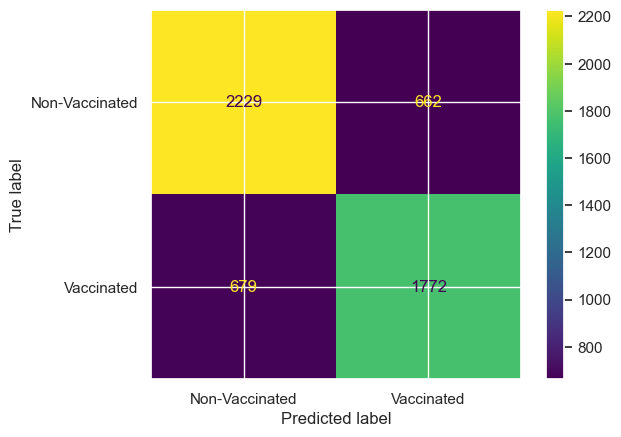

In [31]:
# Evaluate the model using Confusion Matrix

# Define Confusion Matrix
cm = confusion_matrix(y_test, y_test_log_preds, labels=[0,1])

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Non-Vaccinated', 'Vaccinated'])
disp.plot()

***

**Confusion Matrix Insights:**

**True Negatives (TN):** 2229. The model correctly identified these people as not getting the vaccine.

**False Positives (FP):** 662. The model predicted they would get vaccinated, but they didn't. 

**False Negatives (FN):** 679. The model predicted they wouldn't get vaccinated, but they actually did.

**True Positives (TP):** 1772. The model correctly identified these people as getting the vaccine.

***

Then we will evaluate it using Classsification Report and ROC AUC Score.

In [32]:
# Evaluate the model using Classsification Report and ROC AUC Score
print("Classification Report:\n", classification_report(y_test, y_test_log_preds))
print("ROC AUC Score:", roc_auc_score(y_test, y_test_log_preds))

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.77      0.77      2891
           1       0.73      0.72      0.73      2451

    accuracy                           0.75      5342
   macro avg       0.75      0.75      0.75      5342
weighted avg       0.75      0.75      0.75      5342

ROC AUC Score: 0.7469918531900448


***

**Classification Report:**

**Class 0: The "Non-Vaccinated" Group**

- **Precision for Class 0 (No Seasonal Vaccine) = 0.77**: This means that when the model labelled someone as "Non-Vaccinated", it is correct 77% of the time and 23% of the time, that person actually did get the shot.


- **Recall for Class 0 (No Seasonal Vaccine) = 0.77:** The model correctly identified 77% of all actual "Unvaccinated" cases.


- **F1-score for Class 0 = 0.77:** Since precision and recall are identical, the model is perfectly balanced for this class (0).


**Class 1: The "Vaccinated" Group**

- **Precision for Class 1 (Seasonal Vaccine) = 0.73:** The model was correct 73% of the time when predicting "Seasonal Vaccine".


- **Recall for Class 1 (Seasonal Vaccine) = 0.72:** The model correctly identified only 72% of actual seasonal vaccine cases. It "missed" about 28% (False Negatives).


- **F1-score for Class 1 = 0.73:** There's a very tight balance between being precision and being recall.

The classification report highlights a robust performance across both categories. With a **Class 1 F1-score of 0.73**, the model demonstrates that it can identify vaccinated individuals with a high degree of reliability. The parity between precision and recall indicates that the model is well-calibrated and suitable for making balanced predictions in a real-world health scenario.

***

**ROC AUC Score:**

**ROC AUC Score = 0.747:** The model achieved an ROC-AUC score of 0.747, indicating a strong discriminative ability.

This metric confirms that the model can effectively rank individuals by their likelihood of vaccination, performing significantly better than a baseline random classifier (0.50).

The alignment between the ROC-AUC and the overall accuracy (75%) suggests that the model is well-calibrated and that the chosen features provide a consistent signal for prediction.

***

### 4.2 Addressing Class Imbalance with SMOTE

Let's check for the distribution of Not Vaccinated (0) vs. Vaccinated (1) on our original training target variable `(y_train)` to see the magnitude of the imbalance. 

In [33]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

0    11381
1     9984
Name: seasonal_vaccine, dtype: int64
0    0.532694
1    0.467306
Name: seasonal_vaccine, dtype: float64


From this distribution analysis of the seasonal_vaccine target variable, it reveals a highly balanced split of 53.3% (Class 0) and 46.7% (Class 1). 

Given this near-parity, using SMOTE will be unnecessary. Adding synthetic data will create overlapping data points that make it harder for the Logistic Regression to find a clear boundary.


Therefore,we can now evaluate more complex non-linear models e.g., `Random Forest Classification` & `Decision Trees` with confidence that the results will be statistically sound and unbiased.

### **4.3 Random Forest Classification Model**

- To prioritize model robustness over training-set memorization, we applied specific regularization constraints:


- **n_estimators=50:** To ensure an adequate ensemble of trees for robust average predictions.


- **max_depth=5:** To prevent the trees from growing too complex and capturing noise.


- **min_samples_leaf=100:** To ensure each terminal node represents a statistically significant group of individuals.

In [34]:
# Instantiate the Random Forest Classification model
rand_cf = RandomForestClassifier(n_estimators=50, max_depth=5,min_samples_leaf=100, random_state=42)

# Train the model
rand_cf.fit(X_train_final, y_train)

# Generate predictions
y_test_rcf_preds = rand_cf.predict(X_test_final)

# Evaluate accuracy score
train_rand_cf_acc = accuracy_score(y_train, rand_cf.predict(X_train_final))
test_rand_cf_acc = accuracy_score(y_test, y_test_rcf_preds)

print(f"Training accuracy score of Random Forest is : {train_rand_cf_acc}")
print(f"Test accuracy score of Random Forest is : {test_rand_cf_acc}")


Training accuracy score of Random Forest is : 0.7652234963725719
Test accuracy score of Random Forest is : 0.7682515911643579


The test accuracy score `0.768` is actually slightly higher than the training accuracy `0.765` indicating that the model is highly reliable. It treats the test data with the same level of accuracy as the data it was trained on.

This also shows that the model has successfully learned the universal patterns of vaccination behavior within the dataset.

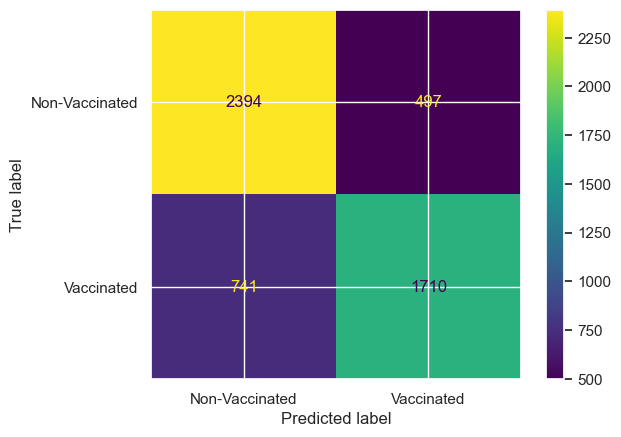

In [35]:
# Evaluate using Confusion Matrix

# Define Confusion Matrix
cm = confusion_matrix(y_test, y_test_rcf_preds, labels=[0,1])

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Non-Vaccinated', 'Vaccinated'])
disp.plot()

***

**Confusion Matrix Insights:**

**True Negatives (TN):** 2394. 

**False Positives (FP):** 497. 

**False Negatives (FN):** 741. 

**True Positives (TP):** 1710. 

***

In [36]:
# Evaluate the model using Classsification Report and ROC AUC Score
print("Classification Report:\n", classification_report(y_test, y_test_rcf_preds))

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.83      0.79      2891
           1       0.77      0.70      0.73      2451

    accuracy                           0.77      5342
   macro avg       0.77      0.76      0.76      5342
weighted avg       0.77      0.77      0.77      5342



**Classification Report:**

**Class 0: The "Non-Vaccinated" Group**

- **Precision for Class 0 (No Seasonal Vaccine)** = 0.76


- **Recall for Class 0 (No Seasonal Vaccine)** = 0.83


- **F1-score for Class 0** = 0.79


**Class 1: The "Vaccinated" Group**

- **Precision for Class 1 (Seasonal Vaccine)** = 0.77 


- **Recall for Class 1 (Seasonal Vaccine)** = 0.70 


- **F1-score for Class 1** = 0.73

With a **Recall** of `0.83`, this model is excellent at identifying people who did not get the vaccine therefore it makes it a great tool for identifying the "base" population.

Whereas, the **Precision** of `0.77` for the vaccinated group is actually slightly higher than for the non-vaccinated group. This means the model predicts "Vaccinated people" correctly 77% of the time.

The balanced macro average **F1-score** of `0.76` validates that the model performs equitably across both classes, making it a robust tool for predicting seasonal vaccine uptake.

In [37]:
# Check ROC AUC Score
print("ROC AUC Score:", roc_auc_score(y_test, y_test_rcf_preds))

ROC AUC Score: 0.7628807928374345


The **ROC-AUC score** improved to `0.763`, a notable increase over the Logistic Regression baseline.

The improvement indicates that the Random Forest ensemble is superior at separating 'Vaccinated' from 'Non-Vaccinated' individuals. It helps us accurately target the right people for health outreach instead of guessing based on the majority.

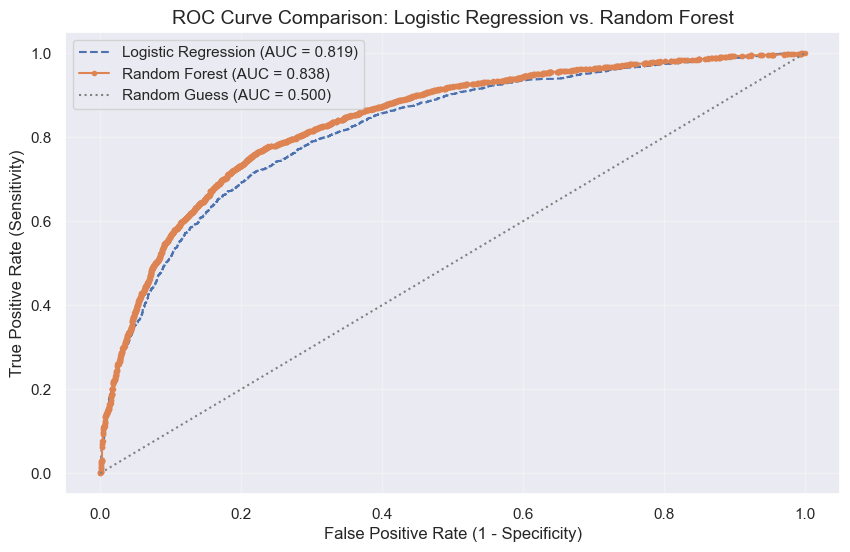

In [38]:
# 1. Get probabilities for the 'Vaccinated' class (column index 1)
lr_probs = Model.predict_proba(X_test_final)[:, 1]
rf_probs = rand_cf.predict_proba(X_test_final)[:, 1]

# 2. Calculate the ROC curve points
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(lr_fpr, lr_tpr, linestyle='--', label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.3f})')
plt.plot(rf_fpr, rf_tpr, marker='.', label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.3f})')

# 4. Plot the "Random Guess" diagonal line
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Random Guess (AUC = 0.500)')

# Formatting the chart
plt.title('ROC Curve Comparison: Logistic Regression vs. Random Forest', fontsize=14)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()